In [1]:
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
# Set default figuresize and font size and labelsize for plots
plt.rcParams['figure.figsize'] = (16, 8)
plt.rcParams['font.size'] = 25
plt.rcParams['axes.labelsize'] = 25
plt.rcParams['xtick.labelsize'] = 25
plt.rcParams['ytick.labelsize'] = 25
mpl.rcParams['mathtext.fontset'] = 'stix'
mpl.rcParams['font.family'] = 'STIXGeneral'

from glob import glob

In [2]:
def calculate_PAO_spectrum(e_eV):
    """
    Calculate the CR flux measured by PAO in 10 ** 17 eV < E < 10 ** 20 eV
    with the SD-750 and SD-1500.
    The formula of the spectrum is Equation (13) of
    Abreu et al., Eur. Phys. J. C 81, 966 (2021)
    (https://doi.org/10.1140/epjc/s10052-021-09700-w)
    """


    j_0 = 1.309e-18 # km^-2 yr^-1 sr^-1 eV^-1
    e_0 = 10 ** 18.5 # eV
    omega_01, omega_12, omega_23, omega_34 = 0.43, 0.05, 0.05, 0.05
    g_0, g_1, g_2, g_3, g_4 = 2.64, 3.298, 2.52, 3.08, 5.2
    e_01, e_12, e_23, e_34 = 1.24e17, 4.9e18, 1.4e19, 4.7e19 # eV

    j = j_0 * (e_eV/e_0) ** (-g_0) \
            * (1 + (e_eV/e_01) ** (1/omega_01)) ** ((g_0-g_1) * omega_01) \
            * (1 + (e_eV/e_12) ** (1/omega_12)) ** ((g_1-g_2) * omega_12) \
            * (1 + (e_eV/e_23) ** (1/omega_23)) ** ((g_2-g_3) * omega_23) \
            * (1 + (e_eV/e_34) ** (1/omega_34)) ** ((g_3-g_4) * omega_34) \
            / (1 + (e_0/e_01)  ** (1/omega_01)) ** ((g_0-g_1) * omega_01) \
            / (1 + (e_0/e_12)  ** (1/omega_12)) ** ((g_1-g_2) * omega_12) \
            / (1 + (e_0/e_23)  ** (1/omega_23)) ** ((g_2-g_3) * omega_23) \
            / (1 + (e_0/e_34)  ** (1/omega_34)) ** ((g_3-g_4) * omega_34)

    return j

# PWF quantification

In [3]:
def plot_loghist(x, bins, label, alpha, density=False,range=None):
    """
    Plot histogram in log scale
    """
    hist, bins = np.histogram(x, bins=bins, range=range)
    logbins = np.logspace(np.log10(bins[0]),np.log10(bins[-1]),len(bins))
    plt.hist(x, bins=logbins, label=label, alpha=alpha, density=density)
    plt.xscale('log')


path_data = "/pbs/home/j/jlavoisier/pipeline_lab/SWF_quant/out_files/data_chi2_n_ant.npy"
# path_sim = sorted(glob("/pbs/home/j/jlavoisier/pipeline_lab/SWF_quant/out_files/batch/adc*"))
path_sim = sorted(glob("/sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN*PWF*"))


chi2_sims = np.array([])
n_ant_trig_sims = np.array([])
theta_sims = np.array([])
phi_sims = np.array([])
theta_true = np.array([])
phi_true = np.array([])

for i in range(len(path_sim)):
    file_sims = np.load(path_sim[i])
    print("Number of simulated events in file ", path_sim[i], " : ", len(file_sims[0]))
    n_ant_trig_sims = np.append(n_ant_trig_sims, file_sims[0])
    chi2_sims = np.append(chi2_sims, file_sims[1])
    theta_sims = np.append(theta_sims, file_sims[2])
    phi_sims = np.append(phi_sims, file_sims[3])
    theta_true = np.append(theta_true, file_sims[4])
    phi_true = np.append(phi_true, file_sims[5])

print("Number of simulated events processed : ", len(chi2_sims))


Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0001_chi2_PWF_n_ant.npy  :  0
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0002_chi2_PWF_n_ant.npy  :  0
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0003_chi2_PWF_n_ant.npy  :  0
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0004_chi2_PWF_n_ant.npy  :  146


Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0005_chi2_PWF_n_ant.npy  :  456
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0006_chi2_PWF_n_ant.npy  :  691
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0007_chi2_PWF_n_ant.npy  :  358
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0008_chi2_PWF_n_ant.npy  :  0
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0009_chi2_PWF_n_ant.npy  :  22
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0010_chi2_PWF_n_ant.npy  :  280
Number of simulated events in file  /sps/grand/jlavoisier/code/quantification/SWF_quant/out_files/batch/ZHAiReS/AN_0011_c

In [4]:
# For energy import

path = f"/sps/grand/jlavoisier/code/quantification/check_sims/out_files/simsGP300NJ_theta_n_ant_energy.npy"

file_sims = np.load(path)

theta_tot = file_sims[0]
phi_tot = file_sims[1]
n_ant_trig_tot = file_sims[2]
energy_tot = file_sims[3]

theta = theta_tot[n_ant_trig_tot >= 5]
phi = phi_tot[n_ant_trig_tot >= 5]
energy = energy_tot[n_ant_trig_tot >= 5]

print(len(theta_true))
print(len(theta))

3496
3496


In [5]:
parasites_chi2_PWF_RUN = np.load(f"/sps/grand/jlavoisier/code/quantification/check_data/data/chi2_PWF_parasites.npy",
                    allow_pickle=True
                    ).item()
parasites_theta_RUN = np.load("/sps/grand/jlavoisier/code/quantification/check_data/data/theta_parasites.npy",
                    allow_pickle=True
                    ).item()
parasites_phi_RUN = np.load("/sps/grand/jlavoisier/code/quantification/check_data/data/phi_parasites.npy",
                    allow_pickle=True
                    ).item()



PWF_RUNs = np.array(list(parasites_chi2_PWF_RUN.keys()))


parasites_PWF_chi2 = np.array([])
parasites_theta = np.array([])
parasites_phi = np.array([])

for run in PWF_RUNs:
    parasites_PWF_chi2 = np.concatenate((parasites_PWF_chi2, parasites_chi2_PWF_RUN[run]))
    parasites_theta = np.concatenate((parasites_theta, parasites_theta_RUN[run]))
    parasites_phi = np.concatenate((parasites_phi, parasites_phi_RUN[run]))

print("Number of parasites events processed in chi2: ", len(parasites_PWF_chi2))
print("Number of parasites events processed in theta: ", len(parasites_theta))

mask_zenith = (parasites_theta*180/np.pi >= 60) & (parasites_theta*180/np.pi <= 88)
mask_mine = (parasites_phi*180/np.pi >= 280) & (parasites_phi*180/np.pi <= 315)

Number of parasites events processed in chi2:  5455335
Number of parasites events processed in theta:  5455335


In [6]:

# Weights per bin
weights_energy_events = np.zeros(len(energy))
for i in range(len(energy)):
    weights_energy_events[i] = calculate_PAO_spectrum(energy[i] * 1e9) # The weight for the energy bin

weights_energy_events = calculate_PAO_spectrum(energy * 1e9)

weights_zenith_events = np.sin(theta * np.pi / 180) * np.cos(theta * np.pi / 180) # The weight for the zenith bin

weights_events = weights_energy_events * weights_zenith_events

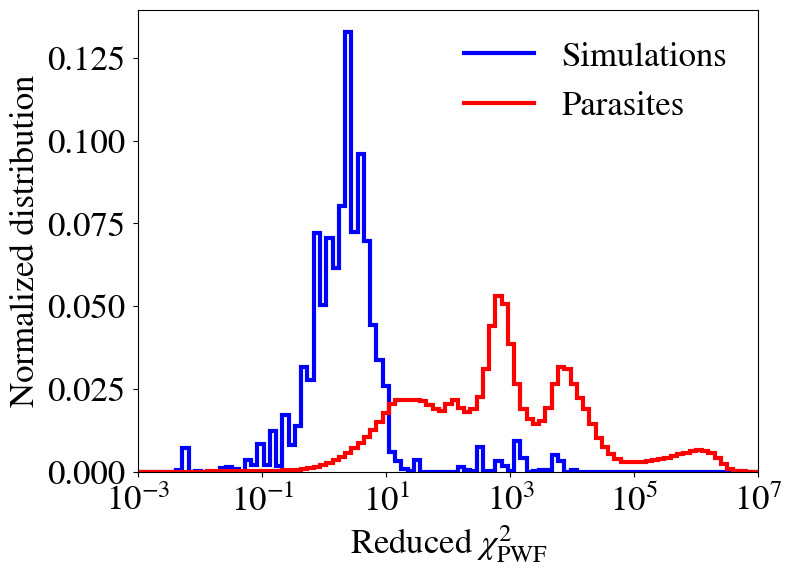

In [23]:
logbins = np.logspace(-3, 7, 100)

fig = plt.figure(figsize=(8, 6))

hist_chi2_sims, _ = np.histogram(chi2_sims, 
                                 bins=logbins,
                                 weights=weights_events
                                 )
norm_hist_chi2_sims = hist_chi2_sims / np.sum(weights_events)
# norm_hist_chi2_sims = hist_chi2_sims / np.sum(hist_chi2_sims)

plt.stairs(norm_hist_chi2_sims, 
           logbins, 
           label='Simulations', 
        #    alpha=0.5, 
           color='blue',
           linewidth=3,
           )

hist_chi2_data, _ = np.histogram(parasites_PWF_chi2, 
                                 bins=logbins
                                 )
norm_hist_chi2_data = hist_chi2_data / np.sum(hist_chi2_data)
plt.stairs(norm_hist_chi2_data, 
           logbins, 
           label='Parasites', 
        #    alpha=0.5, 
           color='red',
              linewidth=3
           )

plt.xlabel(r'Reduced $\chi^2_{\rm PWF}$')
plt.ylabel('Normalized distribution')
plt.xscale('log')
plt.xlim(1e-3, 1e7)
# plt.title(r'Normalized distribution of Reduced $\chi^2_{\rm PWF}$')
plt.legend(frameon=False)


plt.tick_params(axis='both', 
                    # labelsize=27,
                    # direction="in",
                    pad=6
                    )

plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/PWF_chi2_distrib_total.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )

plt.show()

Cut efficiency for PWF for loss rate < 1% : 33.65%
Chi2 limit for PWF for loss rate < 1% : 1.83e+03


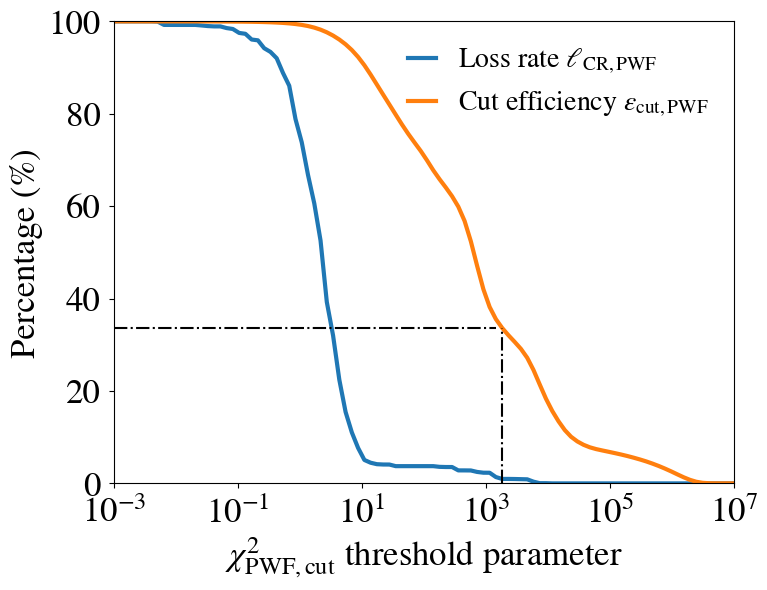

In [24]:
chi2_limit = np.logspace(-3,7, 100)

loss_rate = 1 - np.array([np.sum(weights_events[chi2_sims<chi2_limit[i]])/np.sum(weights_events) for i in range(len(chi2_limit))])
cut_efficency = 1 -np.array([len(parasites_PWF_chi2[parasites_PWF_chi2<chi2_limit[i]])/len(parasites_PWF_chi2) for i in range(len(chi2_limit))])

# print("Loss rate for PWF : ", loss_rate)

fig = plt.figure(figsize=(8, 6))
plt.plot(chi2_limit, 
         100*loss_rate, 
         label=r"Loss rate $\ell_{\rm CR, PWF}$",
         linewidth=3,
         )

plt.plot(chi2_limit, 
         100*cut_efficency, 
         label=r"Cut efficiency $\epsilon_{\rm cut, PWF}$",
            linewidth=3
         )



index_first_99 = np.where(loss_rate < 0.01)[0][0]
plt.plot(chi2_limit[index_first_99]+np.zeros(50),
         np.linspace(0, 100*cut_efficency[index_first_99], 50),
         color='black',
         linestyle='-.',
        #  label=r"$\epsilon_{\rm cut, PWF}$ for $\ell_{\rm CR, PWF}$ < 1%"
         )
plt.plot(chi2_limit[:index_first_99],
         100*cut_efficency[index_first_99]+np.zeros(len(chi2_limit[:index_first_99])),
         linestyle='-.',
         color='black',
        #  label=r"Cut eff for $\ell$ < 1%: {:.2f}%".format(100*cut_efficency[index_first_99])
         )

# plt.annotate(f"{100*cut_efficency[index_first_99]:.2f}%",
#              xy=(0.8, 0.9),
#              xytext=(1e-2, 35),
#              fontsize=23
#              )

print(f"Cut efficiency for PWF for loss rate < 1% : {100*cut_efficency[index_first_99]:.2f}%")

# plt.annotate(r"$\ell_{\rm CR, PWF} < 1\%$",
#              xy=(0.8, 0.9),
#              xytext=(1e4, 10),
#              fontsize=23
#              )

print(f"Chi2 limit for PWF for loss rate < 1% : {chi2_limit[index_first_99]:.2e}")

plt.xlabel(r"$\chi^2_{\rm PWF, cut}$ threshold parameter",
            fontsize=25
            )
plt.xscale('log')
plt.xlim(xmin=chi2_limit[0], 
         xmax=chi2_limit[-1]
         )
plt.ylim(0,100)
plt.ylabel("Percentage (%)", 
           fontsize=25
           )

# plt.legend(fontsize=20,
#            loc='center left', 
#            bbox_to_anchor=(-0.15, 1.05, 1, 0.1),
#            ncol=2,
#            columnspacing=0.5,
#            frameon=False
#            )
plt.legend(fontsize=20,
           loc="upper right",
           frameon=False,
           handlelength=1
           )

plt.tick_params(axis='both', 
                    # labelsize=23,
                    # direction="in",
                    pad=6
                    )

# plt.grid()
plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/PWF_loss_rate_total.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )
plt.show()

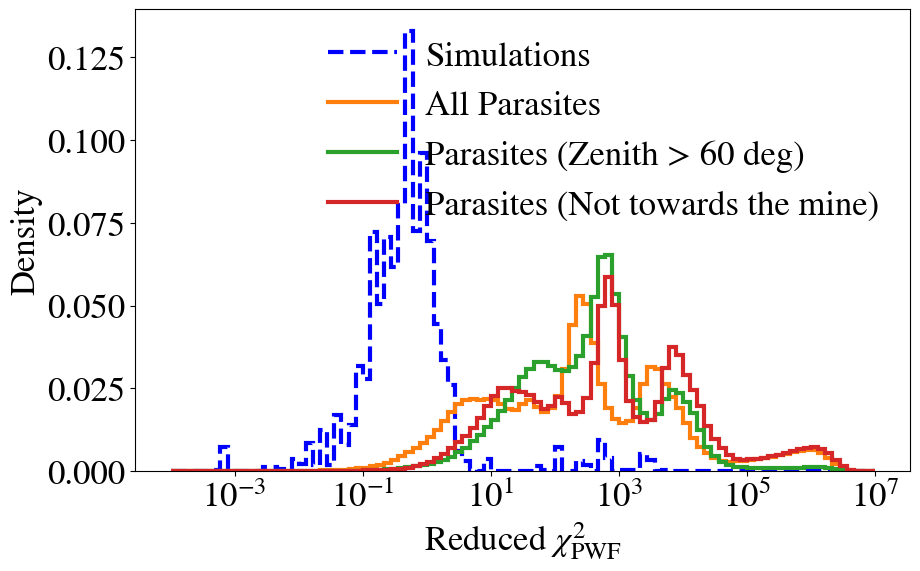

In [9]:
logbins = np.logspace(-4, 7, 100)

fig = plt.figure(figsize=(10, 6))

plt.stairs(norm_hist_chi2_sims, 
           logbins, 
           label='Simulations', 
        #    alpha=0.5, 
           color='blue',
           linewidth=3,
           linestyle='--'
           )

plt.stairs(norm_hist_chi2_data, 
           logbins, 
           label='All Parasites', 
        #    alpha=0.5, 
           color='tab:orange',
           linewidth=3
           )

hist_chi2_zenith, _ = np.histogram(parasites_PWF_chi2[mask_zenith], bins=logbins)
norm_hist_chi2_zenith = hist_chi2_zenith / np.sum(hist_chi2_zenith)
plt.stairs(norm_hist_chi2_zenith, 
           logbins, 
           label='Parasites (Zenith > 60 deg)', 
        #    alpha=0.5, 
           color='tab:green',
           linewidth=3
           )

hist_chi2_mine, _ = np.histogram(parasites_PWF_chi2[~mask_mine], bins=logbins)
norm_hist_chi2_mine = hist_chi2_mine / np.sum(hist_chi2_mine)
plt.stairs(norm_hist_chi2_mine, 
           logbins, 
           label='Parasites (Not towards the mine)', 
        #    alpha=0.5, 
           color='tab:red',
           linewidth=3
           )


plt.xlabel(r'Reduced $\chi^2_{\rm PWF}$')
plt.ylabel('Density')
plt.xscale('log')
# plt.xlim(1e-1, 1e8)
# plt.title(r'Normalized distribution of Reduced $\chi^2_{\rm PWF}$')
plt.legend(frameon=False)
plt.show()

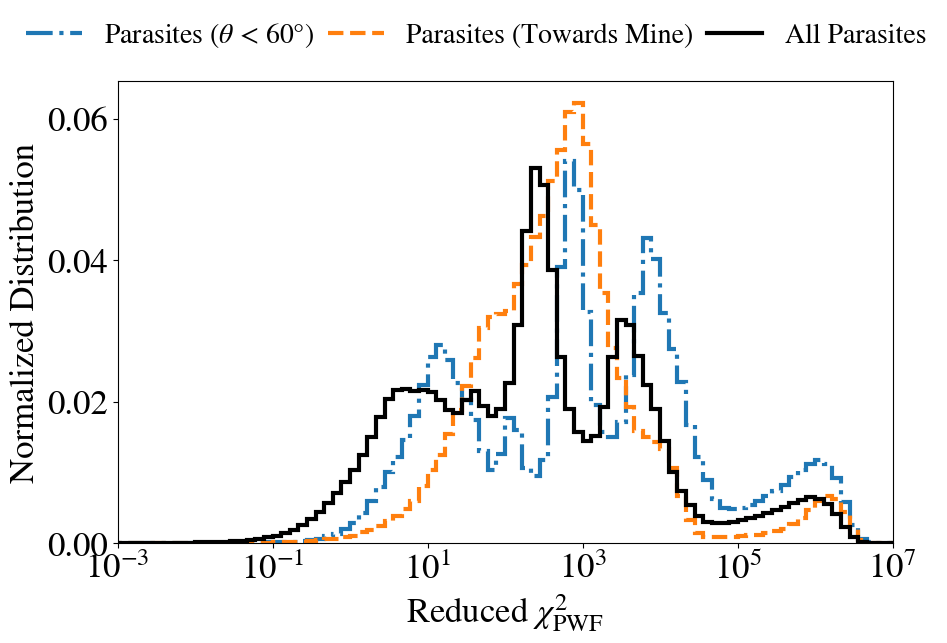

In [10]:
fig = plt.figure(figsize=(10, 6))

hist_chi2_zenith, _ = np.histogram(parasites_PWF_chi2[~mask_zenith], bins=logbins)
norm_hist_chi2_zenith = hist_chi2_zenith / np.sum(hist_chi2_zenith)
plt.stairs(norm_hist_chi2_zenith, 
           logbins, 
           label=r'Parasites ($\theta$ < 60°)', 
        #    alpha=0.5, 
           color='tab:blue',
           linewidth=3,
           linestyle='-.'
           )

hist_chi2_mine, _ = np.histogram(parasites_PWF_chi2[mask_mine], bins=logbins)
norm_hist_chi2_mine = hist_chi2_mine / np.sum(hist_chi2_mine)
plt.stairs(norm_hist_chi2_mine, 
           logbins, 
           label=r'Parasites (Towards Mine)', 
        #    alpha=0.5, 
           color='tab:orange',
           linewidth=3,
           linestyle='--'
           )

plt.stairs(norm_hist_chi2_data, 
           logbins, 
           label='All Parasites', 
        #    alpha=0.5, 
           color='black',
           linewidth=3
           )

plt.xlabel(r'Reduced $\chi^2_{\rm PWF}$')
plt.ylabel('Normalized Distribution')
plt.xscale('log')
plt.xlim(xmin = 1e-3, 
         xmax = 1e7
         )
# plt.ylim(ymax=0.065)
# plt.title(r'Normalized distribution of Reduced $\chi^2_{\rm SWF}$')
plt.legend(fontsize=20,
           loc='center left', 
           bbox_to_anchor=(-0.15, 1.05, 1, 0.1),
           ncol=3,
           columnspacing=0.5,
           frameon=False
           )


plt.savefig(f"/sps/grand/jlavoisier/code/quantification/0_plots_article/PWF_chi2_distrib_mine_zenith.pdf",
            format='pdf', 
            dpi=300, 
            bbox_inches = "tight"
            )
plt.show()

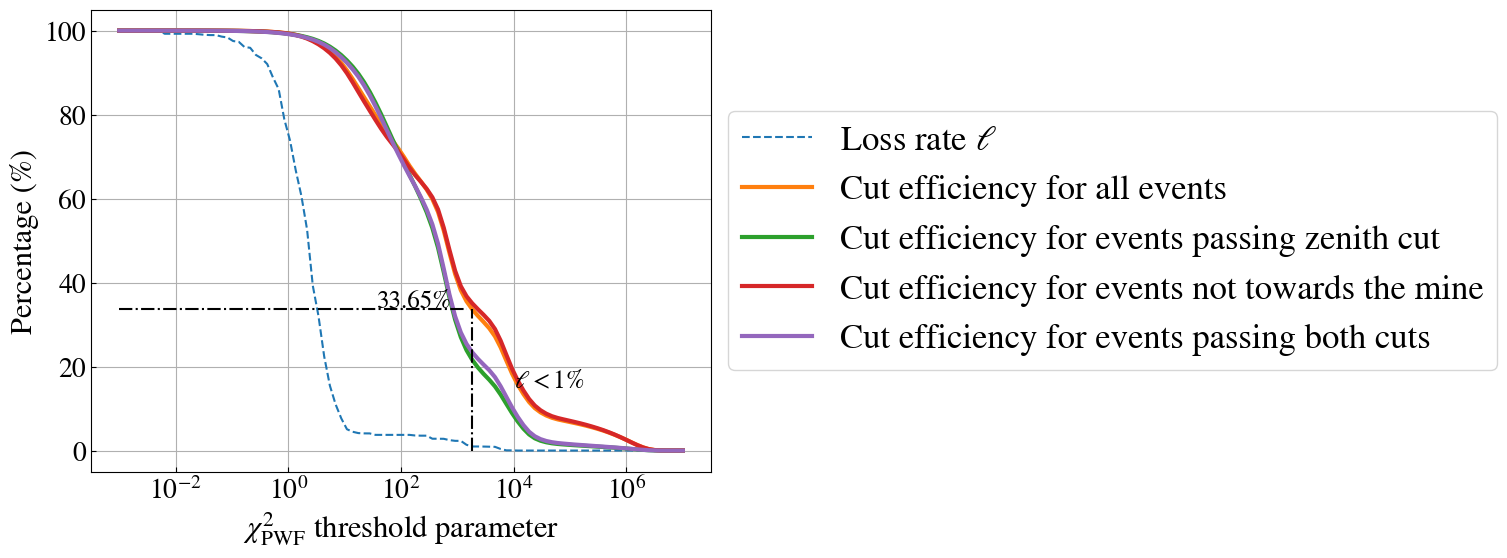

In [11]:
mask_zenith = (parasites_theta*180/np.pi >= 60) & (parasites_theta*180/np.pi <= 88)
mask_mine = (parasites_phi*180/np.pi >= 280) & (parasites_phi*180/np.pi <= 315)

cut_efficency_zenith = 1 - np.array([np.sum(parasites_PWF_chi2[mask_zenith] <chi2_limit[i])/len(parasites_PWF_chi2[mask_zenith]) for i in range(len(chi2_limit))])
cut_efficency_mine = 1 - np.array([np.sum(parasites_PWF_chi2[~mask_mine] <chi2_limit[i])/len(parasites_PWF_chi2[~mask_mine]) for i in range(len(chi2_limit))])
cut_efficency_both = 1 - np.array([np.sum(parasites_PWF_chi2[np.logical_and(mask_zenith, ~mask_mine)] <chi2_limit[i])/len(parasites_PWF_chi2[np.logical_and(mask_zenith, ~mask_mine)]) for i in range(len(chi2_limit))])

fig = plt.figure(figsize=(8, 6))
plt.plot(chi2_limit,    
         100*loss_rate, 
         label=r"Loss rate $\ell$",
         linestyle='--',
         )

plt.plot(chi2_limit, 
         100*cut_efficency, 
         label=r"Cut efficiency for all events",
         linewidth=3
         )


plt.plot(chi2_limit, 
         100*cut_efficency_zenith, 
         label=r"Cut efficiency for events passing zenith cut",
         linewidth=3
         )

plt.plot(chi2_limit, 
         100*cut_efficency_mine, 
         label=r"Cut efficiency for events not towards the mine",
         linewidth=3
         )

plt.plot(chi2_limit, 
         100*cut_efficency_both, 
         label=r"Cut efficiency for events passing both cuts",
         linewidth=3
         )



index_first_99 = np.where(loss_rate < 0.01)[0][0]
plt.plot(chi2_limit[index_first_99]+np.zeros(50),
         np.linspace(0, 100*cut_efficency[index_first_99], 50),
         color='black',
         linestyle='-.',
        #  label=r"Loss rate < 1%"
         )
plt.plot(chi2_limit[:index_first_99],
         100*cut_efficency[index_first_99]+np.zeros(len(chi2_limit[:index_first_99])),
         linestyle='-.',
         color='black',
        #  label=r"Cut eff for $\ell$ < 1%: {:.2f}%".format(100*cut_efficency[index_first_99])
         )

plt.annotate(f"{100*cut_efficency[index_first_99]:.2f}%",
             xy=(0.8, 0.9),
             xytext=(37, 34),
             fontsize=18
             )

plt.annotate(r"$\ell < 1\%$",
             xy=(0.8, 0.9),
             xytext=(1e4, 15),
             fontsize=18
             )




plt.xlabel(r"$\chi^2_{\rm PWF}$ threshold parameter",
            fontsize=22)
plt.xscale('log')
plt.ylabel("Percentage (%)", 
           fontsize=22)
plt.legend(loc='center left', 
           bbox_to_anchor=(1, 0.5)
           )
plt.tick_params(axis='both', 
                    labelsize=20,
                    direction="in"
                    )
# plt.xlim(chi2_limit[0], chi2_limit[-1])
plt.grid()
plt.show()